In [29]:
import os
from getpass import getpass

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass("Enter your Google API Key: ")

In [30]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [31]:
import google.genai as genai

client = genai.Client()

for model in client.models.list():
    print(model.name)


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025
models/ge

In [32]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [33]:
def chatbot_node(state: State):
    response = llm.invoke(state["messages"])
    
    return {"messages": [response]}

In [34]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver  

checkpointer = InMemorySaver()
builder = StateGraph(State)

builder.add_node("chatbot", chatbot_node)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile(checkpointer=checkpointer)

In [35]:
# user_input = {"messages": [("user", "What is langgraph?")]}
# graph.invoke(user_input)

In [36]:
user_input = {"messages": [("user", "I want to build a pc on which I can play AAA games. Build me a pc with current price in bangladesh")]}
config = {"configurable": {"thread_id": 1}}
for event in graph.stream(user_input, config):
    for value in event.values():
        print("Assistant:", value["messages"][-1].content)

Assistant: [{'type': 'text', 'text': 'Building a gaming PC in Bangladesh requires balancing performance with the current market prices, which are influenced by the US dollar rate.\n\nTo play **AAA games** (like Cyberpunk 2077, RDR2, Starfield, or Warzone), I have designed three builds based on different budgets.\n\n---\n\n### Option 1: The "1080p Value King" (Budget Friendly)\n*Target: 60+ FPS on High/Ultra settings at 1080p.*\n\n*   **CPU:** Intel Core i5-12400F (Tray + Cooler) — 13,500 TK\n*   **Motherboard:** Gigabyte H610M S2H V2 — 10,500 TK\n*   **GPU:** Sapphire Pulse RX 6600 8GB GDDR6 — 27,500 TK\n*   **RAM:** Corsair Vengeance LPX 16GB (8x2) 3200MHz — 5,000 TK\n*   **SSD:** HP EX900 Plus 512GB NVMe M.2 — 4,500 TK\n*   **PSU:** Corsair CV550 550 Watt 80 Plus Bronze — 5,200 TK\n*   **Casing:** Value Top / Revenger (with 3-4 fans) — 3,500 TK\n*   **Total Estimate:** **~69,700 BDT**\n\n---\n\n### Option 2: The "Sweet Spot" (Recommended for AAA)\n*Target: 80+ FPS on Ultra settings a

In [37]:
user_input = {"messages": [("user", "I Forgot to add mouse and keyboard as well to buy. Add the cost of these to previous cost and give me total cost")]}

graph.invoke(user_input, config)

{'messages': [HumanMessage(content='I want to build a pc on which I can play AAA games. Build me a pc with current price in bangladesh', additional_kwargs={}, response_metadata={}, id='be78fa8c-6518-41fc-9908-e9b5ecb92799'),
  AIMessage(content=[{'type': 'text', 'text': 'Building a gaming PC in Bangladesh requires balancing performance with the current market prices, which are influenced by the US dollar rate.\n\nTo play **AAA games** (like Cyberpunk 2077, RDR2, Starfield, or Warzone), I have designed three builds based on different budgets.\n\n---\n\n### Option 1: The "1080p Value King" (Budget Friendly)\n*Target: 60+ FPS on High/Ultra settings at 1080p.*\n\n*   **CPU:** Intel Core i5-12400F (Tray + Cooler) — 13,500 TK\n*   **Motherboard:** Gigabyte H610M S2H V2 — 10,500 TK\n*   **GPU:** Sapphire Pulse RX 6600 8GB GDDR6 — 27,500 TK\n*   **RAM:** Corsair Vengeance LPX 16GB (8x2) 3200MHz — 5,000 TK\n*   **SSD:** HP EX900 Plus 512GB NVMe M.2 — 4,500 TK\n*   **PSU:** Corsair CV550 550 Wat

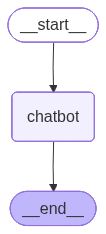

In [38]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph compiled! (Install pygraphviz for visual diagram)")